# Paper figures

All figures for the paper, built **only** from the frozen result files of the full-year
2024 run. Nothing is re-solved here, and nothing under `results/` is written to.

Sources
- `results/year_2024/daily_results.csv` — one row per business day
- `results/year_2024/schedule_opt_long.csv` / `schedule_asap_long.csv` — committed 15-min schedules
- `results/year_2024/run_config.json` — model parameters
- `templates/*.csv` — raw 1-min session load profiles

Output: 300 dpi PNG in `figures/paper/`.

## 1 — Imports, style, palette, paths

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
import matplotlib.dates as mdates

# ---------------------------------------------------------------- palette
MILL   = "#1f5fbf"   # accent 1, blue   -> Chiron 800 CNC mill
PRESS  = "#e8720c"   # accent 2, orange -> HML MP 50 1 VK chip press
INK    = "#1a1a1a"   # primary text
SECOND = "#4d4d4d"   # secondary text, baseline series
MUTED  = "#808080"   # raw / reference data, ASAP scenario
GRID   = "#e0e0e0"

PALETTE = {"MILL": MILL, "PRESS": PRESS, "INK": INK,
           "SECOND": SECOND, "MUTED": MUTED, "GRID": GRID}

# ---------------------------------------------------------------- style
# No usetex, no pgf backend, so a missing LaTeX install can never break
# this notebook. Figures are exported as 300 dpi PNG only.
mpl.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["DejaVu Serif"],   # bundled with matplotlib
    "font.size":         9,
    "axes.labelsize":    9,
    "axes.titlesize":    9,
    "xtick.labelsize":   8,
    "ytick.labelsize":   8,
    "legend.fontsize":   8,
    "axes.edgecolor":    INK,
    "axes.labelcolor":   INK,
    "text.color":        INK,
    "xtick.color":       INK,
    "ytick.color":       INK,
    "axes.linewidth":    0.8,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "axes.grid.axis":    "y",          # horizontal grid only
    "grid.color":        GRID,
    "grid.linewidth":    0.5,
    "axes.axisbelow":    True,         # grid behind the data
    "legend.frameon":    False,
    "figure.dpi":        110,
    "savefig.bbox":      "tight",
    "savefig.pad_inches": 0.02,
})

FIGW = 6.3   # inches, LaTeX textwidth of a standard article class

# ---------------------------------------------------------------- paths
ROOT     = Path.cwd()
RESULTS  = ROOT / "results" / "year_2024"
TEMPLATE = ROOT / "templates"
FIGDIR   = ROOT / "figures" / "paper"
FIGDIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------- showcase day
SHOWCASE_CANDIDATES = ["2024-10-29", "2024-04-17", "2024-11-06"]
SHOWCASE_DAY = "2024-10-29"   # switch here


def save_fig(fig, stem):
    """300 dpi PNG. No PDF export."""
    png = FIGDIR / f"{stem}.png"
    fig.savefig(png, dpi=300)
    print(f"saved  {png.relative_to(ROOT)}")


def hour_axis(ax, label=True):
    """Shared x-axis formatting for the intraday figures (08:00 - 22:00)."""
    ticks = np.arange(8, 23)
    ax.set_xlim(8, 22)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{h:02d}:00" for h in ticks])
    if label:
        ax.set_xlabel("Time of day")


print("style ready, output ->", FIGDIR)

style ready, output -> C:\Users\PCUser\PycharmProjects\industrial-demand-response-study\figures\paper


## 2 — Data loading and sanity checks

In [2]:
daily = pd.read_csv(RESULTS / "daily_results.csv")
opt   = pd.read_csv(RESULTS / "schedule_opt_long.csv")
asap  = pd.read_csv(RESULTS / "schedule_asap_long.csv")
cfg   = json.loads((RESULTS / "run_config.json").read_text())

N_DAYS, N_SLOTS = 252, 56

assert len(daily) == N_DAYS, f"daily_results has {len(daily)} rows, expected {N_DAYS}"
assert len(opt) == N_DAYS * N_SLOTS,  f"schedule_opt_long has {len(opt)} rows"
assert len(asap) == N_DAYS * N_SLOTS, f"schedule_asap_long has {len(asap)} rows"
assert set(daily["termination_condition"]) == {"optimal"}, "not every day solved to optimality"
assert daily["date"].is_unique and opt["date"].nunique() == N_DAYS

for df in (opt, asap):
    df.sort_values(["date", "slot"], inplace=True)
    df.reset_index(drop=True, inplace=True)

daily["date_dt"] = pd.to_datetime(daily["date"])

# slot index -> decimal hour of day (slot 0 = 08:00, slot 55 = 21:45)
SLOT_H = 8.0 + np.arange(N_SLOTS) * 0.25
DAY_END_H = 22.0

# NOTE: saving_pct is per-day and NOT aggregatable (near-zero denominators on
# negative-price days push it between roughly -390 % and +450 %). Every
# percentage below is therefore computed from sums of the euro columns.
cost_opt   = daily["cost_opt_eur"].sum()
cost_asap  = daily["cost_asap_eur"].sum()
saving_eur = daily["saving_eur"].sum()
saving_pct = 100.0 * saving_eur / cost_asap
n_neg_days = int((daily["saving_eur"] < 0).sum())

print(f"business days        : {len(daily)}")
print(f"cost optimized       : {cost_opt:9.2f} EUR")
print(f"cost ASAP baseline   : {cost_asap:9.2f} EUR")
print(f"annual saving        : {saving_eur:9.2f} EUR  ({saving_pct:.2f} % of the ASAP bill)")
print(f"days with a loss     : {n_neg_days} of {len(daily)}")
print(f"energy opt / asap    : {daily['energy_opt_kwh'].sum():.1f} / "
      f"{daily['energy_asap_kwh'].sum():.1f} kWh")
print(f"solve time mean/max  : {daily['solve_time_s'].mean():.2f} / "
      f"{daily['solve_time_s'].max():.2f} s")

business days        : 252
cost optimized       :   2423.94 EUR
cost ASAP baseline   :   2948.49 EUR
annual saving        :    524.55 EUR  (17.79 % of the ASAP bill)
days with a loss     : 82 of 252
energy opt / asap    : 35704.9 / 35861.2 kWh
solve time mean/max  : 2.96 / 25.73 s


## 3 — Helper: 15-min aggregation of a 1-min template

In [3]:
def agg15(v):
    """15-min aggregation exactly as the model does it: whole 15-min bins, mean power."""
    v = np.asarray(v, dtype=float)
    n = len(v) // 15
    return v[:n * 15].reshape(n, 15).mean(axis=1)


mill_1min  = pd.read_csv(TEMPLATE / "chiron_session6_min230-380_1min.csv")
press_1min = pd.read_csv(TEMPLATE / "chippress_session4_window_1min.csv")

MILL_TPL  = agg15(mill_1min["P_kW"].values)    # 10 slots, normal mode
PRESS_TPL = agg15(press_1min["P_kW"].values)   #  5 slots

print(f"mill  : {len(mill_1min)} min -> {len(MILL_TPL)} slots, "
      f"{MILL_TPL.sum() * 0.25:.4f} kWh (config: {cfg['run_energies_kwh']['mill_normal']:.4f})")
print(f"press : {len(press_1min)} min -> {len(PRESS_TPL)} slots, "
      f"{PRESS_TPL.sum() * 0.25:.4f} kWh (config: {cfg['run_energies_kwh']['press']:.4f})")

assert np.isclose(MILL_TPL.sum() * 0.25,  cfg["run_energies_kwh"]["mill_normal"], atol=1e-6)
assert np.isclose(PRESS_TPL.sum() * 0.25, cfg["run_energies_kwh"]["press"],       atol=1e-6)
assert len(MILL_TPL) == cfg["slot_durations"]["mill_normal"]
assert len(PRESS_TPL) == cfg["slot_durations"]["press"]

mill  : 150 min -> 10 slots, 13.7984 kWh (config: 13.7984)
press : 75 min -> 5 slots, 15.7364 kWh (config: 15.7364)


### 3b — The eco mill template

Eco mode stretches the session (power x0.75, duration x1.25) and is 13 slots long per
`run_config.json`. Reconstructing that stretch from the raw 1-min profile reproduces the
shape but not the exact numbers: the analytic version below ends up about 0.8 kW per slot
and 1.5 % of the run energy away from what the solver actually dispatched, i.e. the
resampling used inside the model differs in detail from the one reproduced here (13 slots
span 195 min, while a literal x1.25 stretch of the 150-min session is only 187.5 min).

Because the run reconstruction in section 4 must classify runs *exactly*, the eco
template is therefore taken from the committed schedule itself: there are 18 days with
exactly one mill run which is an eco run, and the 13-slot profile is bit-identical on all
of them. The analytic version is kept as a cross-check and asserted to agree within
0.9 kW per slot and 3 % of the run energy, which is enough to confirm that both describe
the same stretched session.

In [4]:
ECO_SLOTS = cfg["slot_durations"]["mill_eco"]        # 13
ECO_P, ECO_T = 0.75, 1.25                            # power x0.75, duration x1.25

# --- analytic reconstruction from the raw 1-min profile -------------------
v = mill_1min["P_kW"].values * ECO_P
t_stretched = np.arange(len(v)) * ECO_T              # 0 .. 186.25 min
t_target = np.arange(ECO_SLOTS * 15)                 # 0 .. 194 min, whole 15-min bins
MILL_ECO_ANALYTIC = agg15(np.interp(t_target, t_stretched, v, right=0.0))

# --- exact profile, read back from the committed schedules ---------------
def _single_eco_profiles():
    out = []
    sel = daily[(daily["n_mill_runs_opt"] == 1) & (daily["n_mill_eco_opt"] == 1)]
    for d in sel["date"]:
        w = opt.loc[opt["date"] == d, "mill_kW"].values
        idx = np.flatnonzero(w > 0)
        if len(idx) == ECO_SLOTS and idx[-1] - idx[0] == ECO_SLOTS - 1:
            out.append(w[idx])
    return np.array(out)


_eco = _single_eco_profiles()
assert len(_eco) > 0, "no unambiguous single-eco-run day found"
assert np.abs(_eco - _eco[0]).max() < 1e-9, "eco profile is not identical across days"
MILL_ECO_TPL = _eco[0]

_dev = np.abs(MILL_ECO_ANALYTIC - MILL_ECO_TPL).max()
_e_ana, _e_tpl = MILL_ECO_ANALYTIC.sum() * 0.25, MILL_ECO_TPL.sum() * 0.25
print(f"eco template from {len(_eco)} unambiguous days, identical on all of them")
print(f"  dispatched  : {_e_tpl:.4f} kWh (config: {cfg['run_energies_kwh']['mill_eco']:.4f})")
print(f"  analytic    : {_e_ana:.4f} kWh   max slot deviation {_dev:.3f} kW")

assert np.isclose(_e_tpl, cfg["run_energies_kwh"]["mill_eco"], atol=1e-3)
# loose bound: the analytic stretch only has to confirm the shape, it is not used below
assert _dev < 0.9, f"analytic eco reconstruction is off by {_dev:.3f} kW per slot"
assert abs(_e_ana / _e_tpl - 1) < 0.03, "analytic eco energy is off by more than 3 %"

MILL_TEMPLATES = {"normal": MILL_TPL, "eco": MILL_ECO_TPL}

eco template from 18 unambiguous days, identical on all of them
  dispatched  : 13.1495 kWh (config: 13.1496)
  analytic    : 12.9531 kWh   max slot deviation 0.828 kW


## 4 — Helper: run reconstruction, with verification

`results/` holds no runs table, so the committed runs are rebuilt from the long
schedules. A machine is busy where its column is `> 0`; contiguous busy slots form a
block. Back-to-back runs merge into a single block, so each block of length `L` is split:

- press: always 5 slots, `L / 5` runs
- mill: `10a + 13b = L`. For any block that fits inside a 56-slot day this equation has
  exactly one solution (the first collision of the two step sizes is at `L = 130`), so
  the *counts* are unambiguous. The *order* of normal and eco runs inside a merged block
  is resolved by matching the actual slot values against the two mill templates.

The reconstruction is verified against `n_mill_runs_*`, `n_mill_eco_opt` and
`n_press_runs_*` from `daily_results.csv`.

In [5]:
from itertools import permutations

MILL_DUR = {"normal": cfg["slot_durations"]["mill_normal"],
            "eco":    cfg["slot_durations"]["mill_eco"]}
PRESS_DUR = cfg["slot_durations"]["press"]


def busy_blocks(power):
    """[(start_slot, length), ...] for contiguous slots with power > 0."""
    out, i, n = [], 0, len(power)
    while i < n:
        if power[i] > 0:
            j = i
            while j < n and power[j] > 0:
                j += 1
            out.append((i, j - i))
            i = j
        else:
            i += 1
    return out


def _mill_decompositions(L):
    return [(a, b)
            for a in range(L // MILL_DUR["normal"] + 1)
            for b in range(L // MILL_DUR["eco"] + 1)
            if a * MILL_DUR["normal"] + b * MILL_DUR["eco"] == L]


def reconstruct_mill_runs(power, tol=1e-2):
    """[(start_slot, n_slots, 'normal'|'eco'), ...] for one day's mill column."""
    runs = []
    for start, L in busy_blocks(power):
        sols = _mill_decompositions(L)
        assert sols, f"mill block of {L} slots is not a sum of 10 and 13"
        best = None
        for a, b in sols:
            for order in set(permutations(["normal"] * a + ["eco"] * b)):
                cand = np.concatenate([MILL_TEMPLATES[k] for k in order])
                err = np.abs(cand - power[start:start + L]).max()
                if best is None or err < best[0]:
                    best = (err, order)
        err, order = best
        assert err < tol, f"mill block at slot {start} does not match the templates (err {err:.4f} kW)"
        off = start
        for kind in order:
            runs.append((off, MILL_DUR[kind], kind))
            off += MILL_DUR[kind]
    return runs


def reconstruct_press_runs(power, tol=1e-2):
    """[(start_slot, n_slots), ...] for one day's press column."""
    runs = []
    for start, L in busy_blocks(power):
        assert L % PRESS_DUR == 0, f"press block of {L} slots is not a multiple of {PRESS_DUR}"
        for k in range(L // PRESS_DUR):
            off = start + k * PRESS_DUR
            err = np.abs(PRESS_TPL - power[off:off + PRESS_DUR]).max()
            assert err < tol, f"press run at slot {off} does not match the template (err {err:.4f} kW)"
            runs.append((off, PRESS_DUR))
    return runs


def day_runs(date, scenario):
    """scenario in {'opt', 'asap'} -> dict with mill and press runs of that day."""
    src = opt if scenario == "opt" else asap
    g = src[src["date"] == date]
    assert len(g) == N_SLOTS, f"{date}/{scenario}: {len(g)} slots"
    mill = reconstruct_mill_runs(g["mill_kW"].values)
    press = reconstruct_press_runs(g["press_kW"].values)
    return {"mill": mill, "press": press,
            "n_mill": len(mill),
            "n_eco": sum(1 for r in mill if r[2] == "eco"),
            "n_press": len(press)}


def verify_day(date):
    row = daily.loc[daily["date"] == date].iloc[0]
    o, a = day_runs(date, "opt"), day_runs(date, "asap")
    assert o["n_mill"]  == row["n_mill_runs_opt"],  f"{date}: mill opt {o['n_mill']} vs {row['n_mill_runs_opt']}"
    assert o["n_eco"]   == row["n_mill_eco_opt"],   f"{date}: eco opt {o['n_eco']} vs {row['n_mill_eco_opt']}"
    assert o["n_press"] == row["n_press_runs_opt"], f"{date}: press opt {o['n_press']} vs {row['n_press_runs_opt']}"
    assert a["n_mill"]  == row["n_mill_runs_asap"], f"{date}: mill asap {a['n_mill']} vs {row['n_mill_runs_asap']}"
    assert a["n_press"] == row["n_press_runs_asap"], f"{date}: press asap {a['n_press']} vs {row['n_press_runs_asap']}"
    return o, a


# --- acceptance criterion 3: every showcase candidate, not just the default
for d in SHOWCASE_CANDIDATES:
    o, a = verify_day(d)
    print(f"{d}  opt: {o['n_mill']} mill ({o['n_eco']} eco), {o['n_press']} press   |   "
          f"asap: {a['n_mill']} mill, {a['n_press']} press   -> verified")

# --- and, for good measure, the whole year
for d in daily["date"]:
    verify_day(d)
print(f"\nrun reconstruction verified against daily_results.csv for all {len(daily)} business days")

2024-10-29  opt: 3 mill (1 eco), 6 press   |   asap: 3 mill, 8 press   -> verified
2024-04-17  opt: 2 mill (2 eco), 6 press   |   asap: 4 mill, 9 press   -> verified
2024-11-06  opt: 2 mill (1 eco), 6 press   |   asap: 3 mill, 8 press   -> verified



run reconstruction verified against daily_results.csv for all 252 business days


## 5 — Showcase day statistics

In [6]:
assert SHOWCASE_DAY in set(daily["date"]), f"{SHOWCASE_DAY} is not a business day of the run"
_row = daily.loc[daily["date"] == SHOWCASE_DAY].iloc[0]

print(f"showcase day: {SHOWCASE_DAY} ({_row['weekday']})")
print("-" * 52)
for k in ["n_pickups", "demand_modules", "cost_opt_eur", "cost_asap_eur", "saving_eur",
          "saving_pct", "energy_opt_kwh", "energy_asap_kwh", "price_mean", "price_min",
          "price_max", "price_spread_p90_p10", "n_mill_runs_opt", "n_mill_eco_opt",
          "n_press_runs_opt", "n_mill_runs_asap", "n_press_runs_asap",
          "peak_load_opt_kw", "peak_load_asap_kw", "energy_shifted_kwh",
          "solve_time_s", "termination_condition"]:
    val = _row[k]
    print(f"  {k:<22} {val:>10.3f}" if isinstance(val, float) else f"  {k:<22} {val:>10}")

_pick = opt[(opt["date"] == SHOWCASE_DAY) & (opt["pickup"] > 0)][["time_local", "pickup"]]
print("\n  pickups:", ", ".join(f"{t} -> {q:.0f} modules"
                                for t, q in zip(_pick["time_local"], _pick["pickup"])))

showcase day: 2024-10-29 (Tuesday)
----------------------------------------------------
  n_pickups                       2
  demand_modules                340
  cost_opt_eur               16.870
  cost_asap_eur              24.744
  saving_eur                  7.874
  saving_pct                 31.822
  energy_opt_kwh            135.165
  energy_asap_kwh           167.286
  price_mean                162.178
  price_min                 105.450
  price_max                 285.800
  price_spread_p90_p10      144.470
  n_mill_runs_opt                 3
  n_mill_eco_opt                  1
  n_press_runs_opt                6
  n_mill_runs_asap                3
  n_press_runs_asap               8
  peak_load_opt_kw           23.744
  peak_load_asap_kw          23.744
  energy_shifted_kwh         62.546
  solve_time_s                5.668
  termination_condition     optimal

  pickups: 15:00 -> 180 modules, 21:45 -> 160 modules


## 6 — Figure B: session load templates

saved  figures\paper\fig_b_session_templates.png


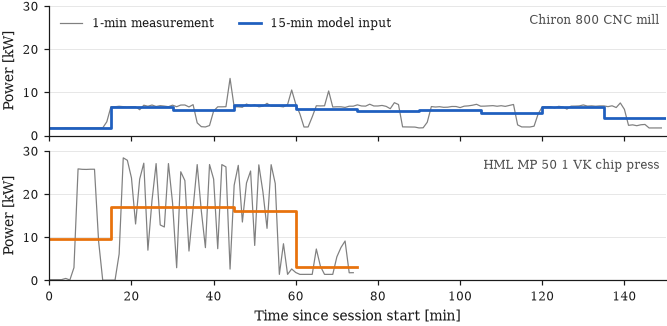

In [7]:
# stacked, sharing one time axis: same minute scale for both machines and no
# empty gap between the panels
fig, axes = plt.subplots(2, 1, figsize=(FIGW, 3.2), sharex=True, sharey=True)

panels = [(axes[0], mill_1min,  MILL_TPL,  MILL,  "Chiron 800 CNC mill"),
          (axes[1], press_1min, PRESS_TPL, PRESS, "HML MP 50 1 VK chip press")]

for ax, raw, tpl, colour, machine in panels:
    ax.plot(raw["t_min"], raw["P_kW"], lw=0.8, color=MUTED, label="1-min measurement")
    # step edges so the last step spans its full 15 minutes as well
    x = np.arange(len(tpl) + 1) * 15
    y = np.r_[tpl, tpl[-1]]
    ax.plot(x, y, drawstyle="steps-post", lw=1.8, color=colour, label="15-min model input")
    ax.text(0.99, 0.94, machine, transform=ax.transAxes, ha="right", va="top",
            fontsize=8, color=SECOND)

# one shared scale, so the two machines can be compared directly
ymax = max(mill_1min["P_kW"].max(), press_1min["P_kW"].max())
axes[0].set_ylim(0, np.ceil(ymax / 5) * 5)
axes[0].set_xlim(0, max(len(MILL_TPL), len(PRESS_TPL)) * 15)
axes[1].set_xlabel("Time since session start [min]")
for ax in axes:
    ax.set_ylabel("Power [kW]")
axes[0].legend(loc="upper left", ncol=2, handlelength=1.8, columnspacing=2.0)

fig.tight_layout()
fig.subplots_adjust(hspace=0.12)
save_fig(fig, "fig_b_session_templates")
plt.show()

## 7 — Figure C: rolling horizon schematic

saved  figures\paper\fig_c_rolling_horizon.png


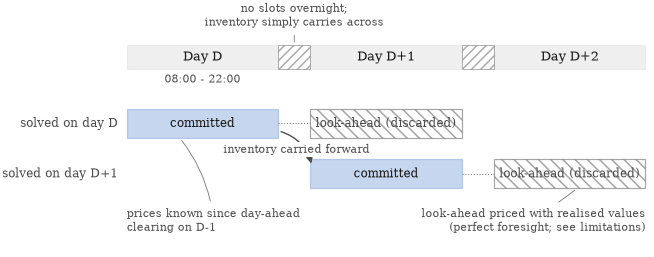

In [8]:
fig, ax = plt.subplots(figsize=(FIGW, 2.6))
ax.set_axis_off()
ax.grid(False)

DAY_W, GAP_W = 14.0, 3.0            # gap drawn narrower than the real 10 h night
day_x = [i * (DAY_W + GAP_W) for i in range(3)]
day_lbl = ["Day D", "Day D+1", "Day D+2"]

Y_DAY, H_DAY = 4.05, 0.45           # calendar strip
Y_W1, Y_W2, H_W = 2.75, 1.80, 0.55  # the two window rows

# --- calendar strip: production days and the overnight gaps ---------------
for x0, lbl in zip(day_x, day_lbl):
    ax.add_patch(Rectangle((x0, Y_DAY), DAY_W, H_DAY, facecolor=GRID, alpha=0.5,
                           edgecolor=GRID, lw=0.8))
    ax.text(x0 + DAY_W / 2, Y_DAY + H_DAY / 2, lbl, ha="center", va="center",
            fontsize=8.5, color=INK)

for x0 in day_x[:-1]:
    ax.add_patch(Rectangle((x0 + DAY_W, Y_DAY), GAP_W, H_DAY, facecolor="white",
                           edgecolor=MUTED, lw=0.6, hatch="////", alpha=0.65))

ax.text(day_x[0] + DAY_W / 2, Y_DAY - 0.10, "08:00 - 22:00", ha="center", va="top",
        fontsize=7, color=SECOND)
ax.annotate("no slots overnight;\n" "inventory simply carries across",
            xy=(day_x[0] + DAY_W + GAP_W / 2, Y_DAY + H_DAY),
            xytext=(day_x[0] + DAY_W + GAP_W / 2, Y_DAY + H_DAY + 0.30),
            ha="center", va="bottom", fontsize=7, color=SECOND,
            arrowprops=dict(arrowstyle="-", lw=0.6, color=MUTED))

# --- the two solve windows ------------------------------------------------
def window_row(y, i_commit):
    """One solved window: committed day i_commit plus look-ahead day i_commit+1."""
    xc, xl = day_x[i_commit], day_x[i_commit + 1]
    ax.add_patch(Rectangle((xc, y), DAY_W, H_W, facecolor=MILL, alpha=0.25,
                           edgecolor=MILL, lw=0.8))
    ax.text(xc + DAY_W / 2, y + H_W / 2, "committed", ha="center", va="center",
            fontsize=8, color=INK)
    ax.add_patch(Rectangle((xl, y), DAY_W, H_W, facecolor="none", edgecolor=MUTED,
                           lw=0.8, hatch="\\\\\\", alpha=0.7))
    ax.text(xl + DAY_W / 2, y + H_W / 2, "look-ahead (discarded)", ha="center",
            va="center", fontsize=8, color=SECOND)
    # one MILP across both days: connect across the night
    ax.plot([xc + DAY_W, xl], [y + H_W / 2, y + H_W / 2], lw=0.7, color=MUTED, ls=":")
    ax.text(day_x[0] - 0.8, y + H_W / 2, f"solved on day D+{i_commit}" if i_commit
            else "solved on day D", ha="right", va="center", fontsize=8, color=SECOND)


window_row(Y_W1, 0)
window_row(Y_W2, 1)

# --- inventory hand-over --------------------------------------------------
ax.annotate("", xy=(day_x[1] + 0.15, Y_W2 + H_W * 0.75),
            xytext=(day_x[0] + DAY_W, Y_W1 + H_W * 0.25),
            arrowprops=dict(arrowstyle="-|>", lw=0.9, color=SECOND,
                            connectionstyle="arc3,rad=-0.3"))
ax.text(day_x[0] + DAY_W + GAP_W / 2 + 0.2, (Y_W1 + Y_W2 + H_W) / 2 - 0.02,
        "inventory carried forward", ha="center", va="center", fontsize=7.5,
        color=SECOND, bbox=dict(facecolor="white", edgecolor="none", pad=1.2))

# --- annotations (kept below the rows so nothing overlaps) ---------------
ax.annotate("prices known since day-ahead\n" "clearing on D-1",
            xy=(day_x[0] + DAY_W * 0.35, Y_W1), xytext=(day_x[0], Y_W2 - 0.35),
            ha="left", va="top", fontsize=7, color=SECOND,
            arrowprops=dict(arrowstyle="-", lw=0.6, color=MUTED,
                            connectionstyle="arc3,rad=0.15"))
ax.annotate("look-ahead priced with realised values\n" "(perfect foresight; see limitations)",
            xy=(day_x[2] + DAY_W * 0.55, Y_W2),
            xytext=(day_x[2] + DAY_W, Y_W2 - 0.35),
            ha="right", va="top", fontsize=7, color=SECOND,
            arrowprops=dict(arrowstyle="-", lw=0.6, color=MUTED))

ax.set_xlim(day_x[0] - 9.5, day_x[-1] + DAY_W + 0.6)
ax.set_ylim(0.55, 5.30)

fig.tight_layout()
save_fig(fig, "fig_c_rolling_horizon")
plt.show()

## 8 — Figure G: dispatch timeline for the showcase day

saved  figures\paper\fig_g_dispatch_2024-10-29.png


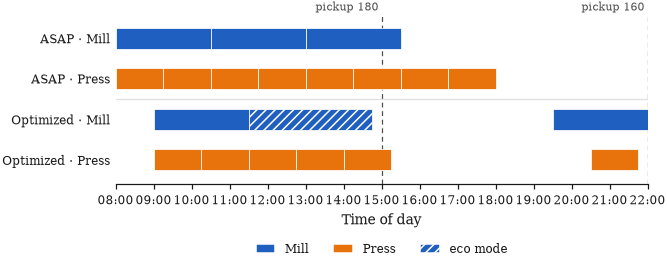

In [9]:
day = SHOWCASE_DAY
runs_opt, runs_asap = verify_day(day)

fig, ax = plt.subplots(figsize=(FIGW, 2.8))
ax.grid(False)

LANE_H = 0.52
lanes = [  # (y position, label, runs, machine colour)
    (3, "ASAP \u00b7 Mill",       runs_asap["mill"],  MILL),
    (2, "ASAP \u00b7 Press",      runs_asap["press"], PRESS),
    (1, "Optimized \u00b7 Mill",  runs_opt["mill"],   MILL),
    (0, "Optimized \u00b7 Press", runs_opt["press"],  PRESS),
]

for y, _lbl, runs, colour in lanes:
    plain = [(SLOT_H[s], n * 0.25) for s, n, *k in runs if not (k and k[0] == "eco")]
    eco   = [(SLOT_H[s], n * 0.25) for s, n, *k in runs if (k and k[0] == "eco")]
    if plain:
        ax.broken_barh(plain, (y - LANE_H / 2, LANE_H), facecolors=colour,
                       edgecolors="white", linewidth=0.5)
    if eco:
        ax.broken_barh(eco, (y - LANE_H / 2, LANE_H), facecolors=colour,
                       edgecolors="white", linewidth=0.5, hatch="////")

# separator between the ASAP pair and the Optimized pair
ax.axhline(1.5, color=GRID, lw=0.8)

# pickup deadlines
picks = opt[(opt["date"] == day) & (opt["pickup"] > 0)]
for _, p in picks.iterrows():
    h = DAY_END_H if int(p["slot"]) == N_SLOTS - 1 else SLOT_H[int(p["slot"])]
    ax.axvline(h, color=SECOND, ls="--", lw=0.8, dashes=(4, 3), zorder=0)
    ax.text(h - 0.08, 3.62, f"pickup {int(p['pickup'])}", rotation=0, ha="right",
            va="bottom", fontsize=7, color=SECOND)

ax.set_yticks([l[0] for l in lanes])
ax.set_yticklabels([l[1] for l in lanes])
ax.set_ylim(-0.6, 3.6)
ax.tick_params(axis="y", length=0)
ax.spines["left"].set_visible(False)
hour_axis(ax)

handles = [Patch(facecolor=MILL, edgecolor="white", label="Mill"),
           Patch(facecolor=PRESS, edgecolor="white", label="Press"),
           Patch(facecolor=MILL, edgecolor="white", hatch="////", label="eco mode")]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.28),
          ncol=3, handlelength=1.6, columnspacing=2.0)

fig.tight_layout()
save_fig(fig, f"fig_g_dispatch_{day}")
plt.show()

## 9 — Figure H: load and price for the showcase day

saved  figures\paper\fig_h_load_price_2024-10-29.png


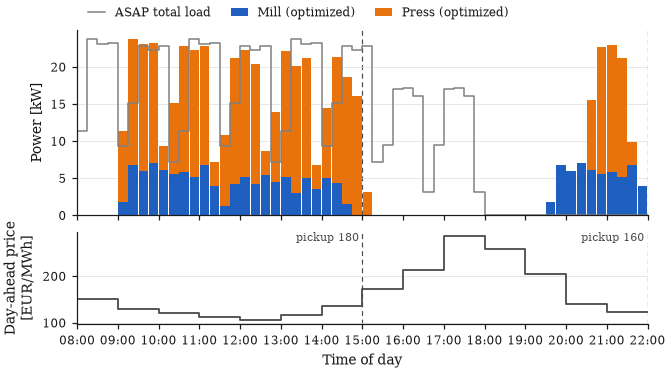

In [10]:
day = SHOWCASE_DAY
g_opt  = opt[opt["date"] == day]
g_asap = asap[asap["date"] == day]

fig, (ax_l, ax_p) = plt.subplots(2, 1, figsize=(FIGW, 3.6), sharex=True,
                                 gridspec_kw={"height_ratios": [2, 1]})

# ---- top: stacked optimized load, ASAP total as reference ---------------
BAR_W = 0.25 * 0.93          # ~2 px white gap between adjacent bars at 300 dpi
xc = SLOT_H + 0.125          # bar centres = middle of the 15-min slot
ax_l.bar(xc, g_opt["mill_kW"], width=BAR_W, color=MILL, label="Mill (optimized)")
ax_l.bar(xc, g_opt["press_kW"], width=BAR_W, bottom=g_opt["mill_kW"], color=PRESS,
         label="Press (optimized)")

x_step = np.r_[SLOT_H, DAY_END_H]
y_step = np.r_[g_asap["total_load_kW"].values, g_asap["total_load_kW"].values[-1]]
ax_l.plot(x_step, y_step, drawstyle="steps-post", lw=1.0, color=MUTED,
          label="ASAP total load")

ax_l.set_ylabel("Power [kW]")
ax_l.set_ylim(bottom=0)
ax_l.legend(loc="lower left", bbox_to_anchor=(0.0, 1.0), ncol=3, handlelength=1.4,
            columnspacing=1.6)

# ---- bottom: day-ahead price -------------------------------------------
price = g_opt["price_eur_mwh"].values
p_step = np.r_[price, price[-1]]
ax_p.plot(x_step, p_step, drawstyle="steps-post", lw=1.2, color=SECOND)
if price.min() < 0:
    ax_p.axhline(0, color=GRID, lw=0.8)
ax_p.set_ylabel("Day-ahead price\n[EUR/MWh]")

# ---- pickup deadlines in both panels ------------------------------------
picks = g_opt[g_opt["pickup"] > 0]
for _, p in picks.iterrows():
    h = DAY_END_H if int(p["slot"]) == N_SLOTS - 1 else SLOT_H[int(p["slot"])]
    for ax in (ax_l, ax_p):
        ax.axvline(h, color=SECOND, ls="--", lw=0.8, dashes=(4, 3), zorder=0)
    ax_p.text(h - 0.08, ax_p.get_ylim()[1], f"pickup {int(p['pickup'])}", ha="right",
              va="top", fontsize=7, color=SECOND)

hour_axis(ax_l, label=False)
hour_axis(ax_p)

fig.tight_layout()
fig.subplots_adjust(hspace=0.12)
save_fig(fig, f"fig_h_load_price_{day}")
plt.show()

## 10 — Figure F: annual savings against price volatility

smoothed series only  |  rolling saving -2.31 .. 14.70 EUR  |  rolling spread 23.6 .. 233.9 EUR/MWh
raw daily range (not plotted): saving -15.70 .. 74.17 EUR, spread 13.7 .. 681.9 EUR/MWh (annual maximum on 06 November)


saved  figures\paper\fig_f_savings_vs_spread.png


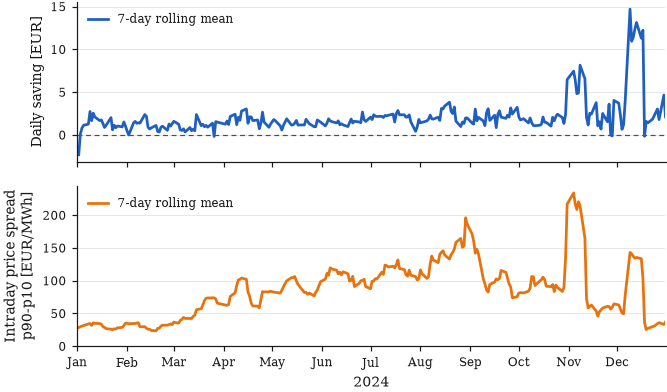

In [11]:
SMOOTHING_WINDOW = 7   # hier glättung anpassen

df = daily.sort_values("date_dt")
x = df["date_dt"]
roll = lambda s: s.rolling(SMOOTHING_WINDOW, center=True, min_periods=1).mean()

fig, (ax_s, ax_v) = plt.subplots(2, 1, figsize=(FIGW, 3.8), sharex=True,
                                 gridspec_kw={"height_ratios": [1, 1]})

# Only the smoothed series are drawn. The raw daily values span -15.7 to
# +74.2 EUR and 8 to 682 EUR/MWh; plotting them compresses both panels to the
# point where the actual movement is no longer readable.

# ---- top: daily saving ---------------------------------------------------
ax_s.axhline(0, color=SECOND, ls="--", lw=0.8, dashes=(4, 3))
ax_s.plot(x, roll(df["saving_eur"]), lw=1.8, color=MILL,
          label=f"{SMOOTHING_WINDOW}-day rolling mean")
ax_s.set_ylabel("Daily saving [EUR]")
ax_s.legend(loc="upper left", handlelength=1.6)

# ---- bottom: intraday price spread ---------------------------------------
spread = df["price_spread_p90_p10"]
ax_v.plot(x, roll(spread), lw=1.8, color=PRESS,
          label=f"{SMOOTHING_WINDOW}-day rolling mean")
ax_v.set_ylim(bottom=0)
ax_v.set_ylabel("Intraday price spread\np90-p10 [EUR/MWh]")
ax_v.legend(loc="upper left", handlelength=1.6)

ax_v.xaxis.set_major_locator(mdates.MonthLocator())
ax_v.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax_v.set_xlim(pd.Timestamp("2024-01-01"), pd.Timestamp("2024-12-31"))
ax_v.set_xlabel("2024")

print(f"smoothed series only  |  rolling saving {roll(df['saving_eur']).min():.2f} .. "
      f"{roll(df['saving_eur']).max():.2f} EUR  |  rolling spread {roll(spread).min():.1f} .. "
      f"{roll(spread).max():.1f} EUR/MWh")
print(f"raw daily range (not plotted): saving {df['saving_eur'].min():.2f} .. "
      f"{df['saving_eur'].max():.2f} EUR, spread {spread.min():.1f} .. {spread.max():.1f} "
      f"EUR/MWh (annual maximum on "
      f"{pd.Timestamp(df.loc[spread.idxmax(), 'date']).strftime('%d %B')})")

fig.tight_layout()
fig.subplots_adjust(hspace=0.15)
save_fig(fig, "fig_f_savings_vs_spread")
plt.show()